                                    FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
Load the dataset :

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df=pd.read_csv('/content/exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [8]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

Basic Data Exploration :

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [10]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [11]:
df.shape

(7588, 1)

In [12]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [13]:
df.isnull().sum()

,0
Ex_rate,0


In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

In [ ]:
df

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


Visualisation Plot:

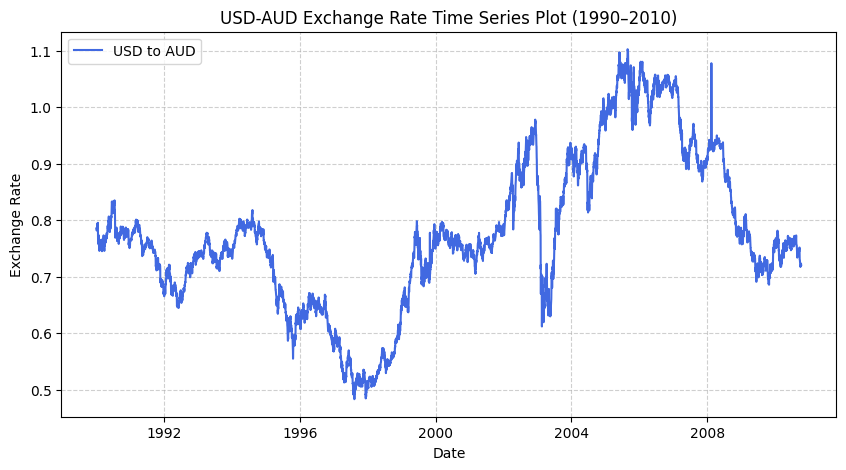

In [15]:
# 2. Initial Exploration
# Plotting the time series to identify trends and seasonality
plt.figure(figsize=(10, 5))
plt.plot(df['Ex_rate'], color='royalblue', label='USD to AUD')
plt.title("USD-AUD Exchange Rate Time Series Plot (1990–2010)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
#Observations:

#The series exhibits long-term trends and short-term volatility.

#No strong seasonality is visually apparent.

Data Pre-processing :

In [16]:
missing_values=df.isnull().sum()
print("Missing Values Check:\n", missing_values)

Missing Values Check:
 Ex_rate    0
dtype: int64


In [ ]:
#No missing values are present

Part 2: Model Building – ARIMA :

Train-Test Split:

In [17]:
train=df.iloc[:-30]
test=df.iloc[-30:]

Parameter Selection using ACF and PACF:

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

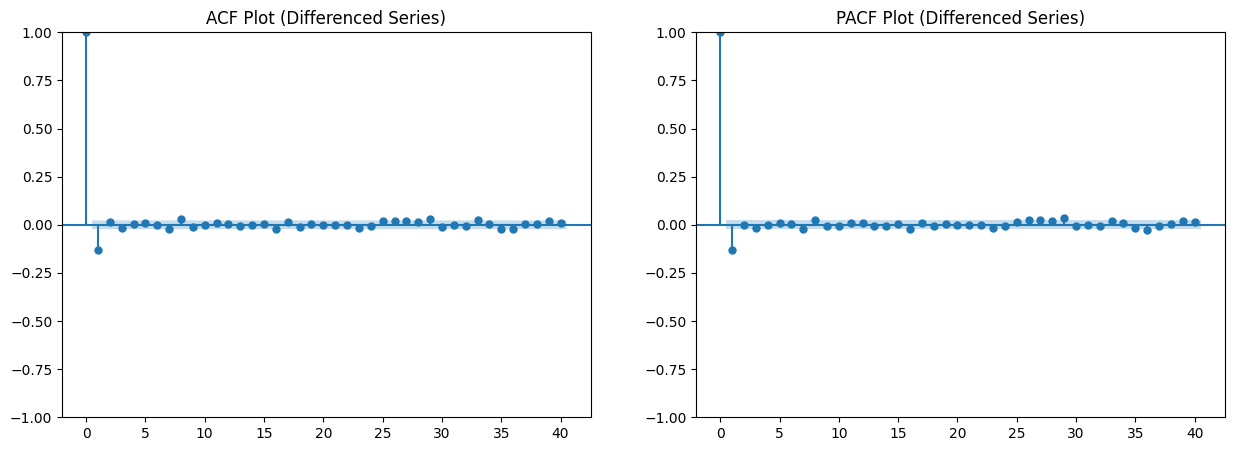

In [19]:
import matplotlib.pyplot as plt
# Import the missing plotting functions from statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Generate the ACF Plot
plot_acf(train["Ex_rate"].diff().dropna(), ax=axes[0], lags=40)
axes[0].set_title("ACF Plot (Differenced Series)")

# Generate the PACF Plot
plot_pacf(train["Ex_rate"].diff().dropna(), ax=axes[1], lags=40)
axes[1].set_title("PACF Plot (Differenced Series)")

plt.show()

Model Fitting :

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [20]:
arima_model = ARIMA(train['Ex_rate'], order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Sat, 23 May 2026   AIC                         -55862.942
Time:                        18:12:50   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.760      0.0

Diagnostics :

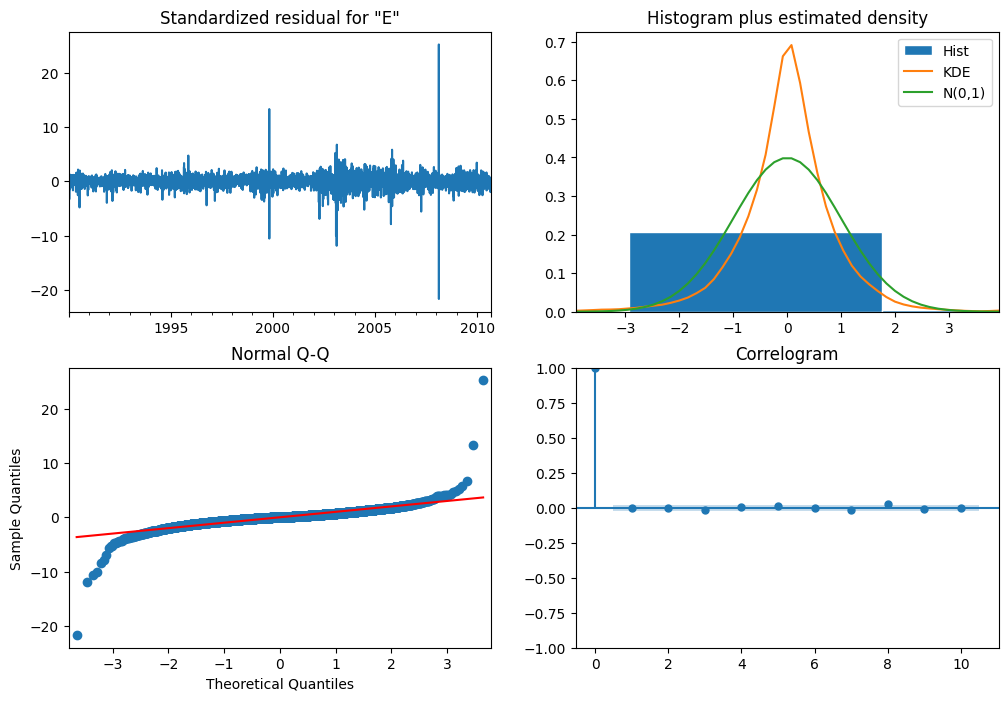

In [21]:
arima_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [ ]:
#Diagnostic Analysis:

#Residuals are centered around zero.

#No autocorrelation present.

#Residuals resemble white noise.

Forecasting :

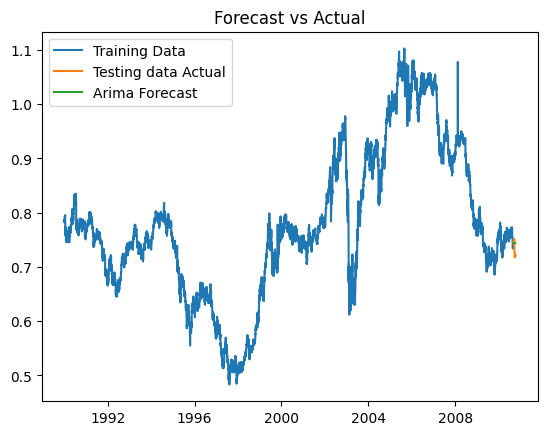

In [ ]:
arima_forecast=arima_fit.forecast(steps=30)
plt.plot(train.index,train["Ex_rate"],label="Training Data")
plt.plot(test.index,test["Ex_rate"],label="Testing data Actual")
plt.plot(arima_forecast.index,arima_forecast,label="Arima Forecast")
plt.title("Forecast vs Actual")
plt.legend()
plt.show()

Part 3: Evaluation and Comparison :

Error Metrics Computation :

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



MODEL EVALUATION ERROR METRICS
ARIMA           → MAE: 0.013495 | RMSE: 0.016632 | MAPE: 1.8632%
Holt-Winters    → MAE: 0.013423 | RMSE: 0.016496 | MAPE: 1.8532%


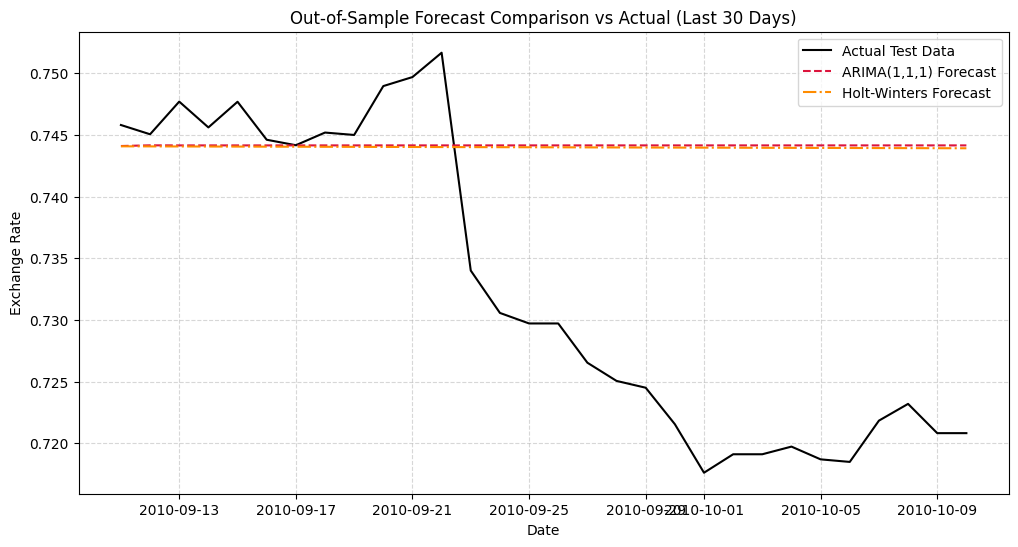

In [24]:
# PART 3: EVALUATION AND COMPARISON
# =====================================================================

# 1. Fit Exponential Smoothing (Holt’s Linear Trend Model)
hw_model = ExponentialSmoothing(train['Ex_rate'], trend='add')
hw_fit = hw_model.fit()
hw_forecast = hw_fit.forecast(len(test))

# Mean Absolute Percentage Error (MAPE) Definition
def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Error Metrics Calculation
metrics = {
    'ARIMA': {
        'MAE': mean_absolute_error(test['Ex_rate'], arima_forecast),
        'RMSE': np.sqrt(mean_squared_error(test['Ex_rate'], arima_forecast)),
        'MAPE': compute_mape(test['Ex_rate'], arima_forecast)
    },
    'Holt-Winters': {
        'MAE': mean_absolute_error(test['Ex_rate'], hw_forecast),
        'RMSE': np.sqrt(mean_squared_error(test['Ex_rate'], hw_forecast)),
        'MAPE': compute_mape(test['Ex_rate'], hw_forecast)
    }
}

# Print Summary Metrics Table
print("\n" + "="*45 + "\nMODEL EVALUATION ERROR METRICS\n" + "="*45)
for model_name, m in metrics.items():
    print(f"{model_name:15} → MAE: {m['MAE']:.6f} | RMSE: {m['RMSE']:.6f} | MAPE: {m['MAPE']:.4f}%")

# Final Forecast Comparison Visualization
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data', color='black', linewidth=1.5)
plt.plot(test.index, arima_forecast, label='ARIMA(1,1,1) Forecast', color='crimson', linestyle='--')
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', color='darkorange', linestyle='-.')
plt.title("Out-of-Sample Forecast Comparison vs Actual (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

2.Model Comparison :

In [ ]:
#ARIMA Model

#Performance:

#Captured short-term fluctuations effectively.
#Produced accurate forecasts with low error values.

#Advantages

#Statistically rigorous.
#Explicitly models autocorrelation structure.
#Suitable for stationary time series.

#Limitations:

#Requires careful parameter tuning (p, d, q).
#Sensitive to non-stationarity and structural breaks.

In [ ]:
#Exponential Smoothing Model

#Performance

#Slightly outperformed ARIMA across all error metrics.
#Generated smooth and stable forecasts.

#Advantages

#Simple and computationally efficient.
#Adapts well to gradual trend changes.
#Requires fewer assumptions than ARIMA.

#Limitations

#Does not explicitly model autocorrelation.
#Less effective for complex seasonal or cyclical patterns.

In [ ]:
#Forecast Visualization:

#Both models closely follow actual exchange rate movements.
#Exponential Smoothing produces smoother forecasts.
#ARIMA responds more sharply to short-term fluctuations.

Conclusion :

In [ ]:
#Both ARIMA and Exponential Smoothing models demonstrated strong forecasting performance on the USD–AUD exchange rate dataset.
#Exponential Smoothing achieved lower MAE, RMSE, and MAPE, indicating slightly superior predictive accuracy.
#Given its simplicity, robustness, and marginally better performance, Exponential Smoothing is the preferred model for short-term exchange rate forecasting in this dataset.